# 05 — Analysis

Load the trained checkpoint, evaluate per-state prediction accuracy,
and compare the model's learned transition probabilities to the true
Gambler's Ruin matrix.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Load model & data

In [2]:
import sys

# Resolve project root and add project-local packages/ to sys.path.
cwd = Path.cwd().resolve()
project_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "packages" / "pytorch_models" / "markov_transformer.py").exists()
    ),
    None,
)
if project_root is None:
    alt_root = cwd / "projects" / "markov-chain-learning"
    if (alt_root / "packages" / "pytorch_models" / "markov_transformer.py").exists():
        project_root = alt_root

if project_root is None:
    raise RuntimeError(
        "Could not locate markov-chain-learning project root from current working directory"
    )

packages_dir = project_root / "packages"
if str(packages_dir) not in sys.path:
    sys.path.insert(0, str(packages_dir))

from pytorch_models import MarkovTransformer

In [3]:
DATA_DIR = str(project_root / "experiments" / "single-chain" / "data")
DATA_DIR = Path(DATA_DIR)
print("Data dir:", DATA_DIR.resolve())

Data dir: /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/single-chain/data


In [4]:
# Reference model = the largest-N MAP from 04's sample-size sweep.
# (04 no longer writes a single checkpoint.pt; per-N MAPs live in sample_size_models/.)
sample_size_model_dir = DATA_DIR / "sample_size_models"
sweep_path = DATA_DIR / "sample_size_sweep.pt"

if not sweep_path.exists():
    raise FileNotFoundError(
        "No sample_size_sweep.pt — run 04_training.ipynb first to train the "
        "per-sample-size MAP checkpoints into sample_size_models/."
    )

_sweep = sorted(torch.load(sweep_path, weights_only=False), key=lambda r: int(r["N"]))
_ref_rec = _sweep[-1]  # largest N
checkpoint_path = sample_size_model_dir / f"checkpoint_N_{int(_ref_rec['N'])}.pt"
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Missing reference checkpoint: {checkpoint_path}")

ckpt = torch.load(checkpoint_path, weights_only=False)
cfg = ckpt["config"]
training_meta = ckpt.get("training", {})

model = MarkovTransformer(**cfg)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(
    f"Loaded {checkpoint_path.name} (N={int(_ref_rec['N'])}) from epoch {ckpt['epoch']} "
    f"(best val loss {ckpt['best_val_loss']:.4f})"
)

data = torch.load(DATA_DIR / "sequences.pt", weights_only=False)
Ts = data["Ts"]
pis = data["pis"]
seqs = data["sequences"]
chain_to_sample = data["chain_to_sample"]
data_cfg = data.get("config", {})

VOCAB = int(cfg["vocab_size"])
PAD_ID = int(data_cfg.get("pad_id", -1))

if Ts.shape[0] == 1:
    T_reference = Ts[0]
    pi_reference = pis[0]
else:
    chain_weights = torch.bincount(chain_to_sample, minlength=Ts.shape[0]).float()
    chain_weights = chain_weights / chain_weights.sum()
    T_reference = (chain_weights[:, None, None] * Ts).sum(dim=0)
    pi_reference = (chain_weights[:, None] * pis).sum(dim=0)

print(f"DGP regime: {data_cfg.get('dgp_regime', 'unknown')}")
print(f"Reference T shape: {tuple(T_reference.shape)}")

Loaded checkpoint_N_3000.pt (N=3000) from epoch 43 (best val loss 1.2433)
DGP regime: single
Reference T shape: (5, 5)


## Generalization loss vs sequence length

Sample `N` sequences with lengths drawn i.i.d. from
$l \sim \text{Uniform}\{2, \ldots, \text{max\_len}\}$.
Run the model on each; collect every valid per-step prediction as an
observation tagged with `(current_state, sequence_length)`.

Three diagnostics:

1. **NLL vs sequence length $l$** (line plot): mean per-token NLL across all
   positions within sequences of total length $l$.  Flat and close to the
   Bayes NLL = the model is length-invariant.

2. **Excess NLL heatmap** (state × $l$): for each (state, sequence-length)
   cell, mean excess NLL.  Should be uniformly near zero.

3. **Per-state excess** (bar chart): excess NLL marginalised over $l$.
   A spike at state $k$ means transitions *out of* $k$ were not learned
   uniformly across sequence lengths.


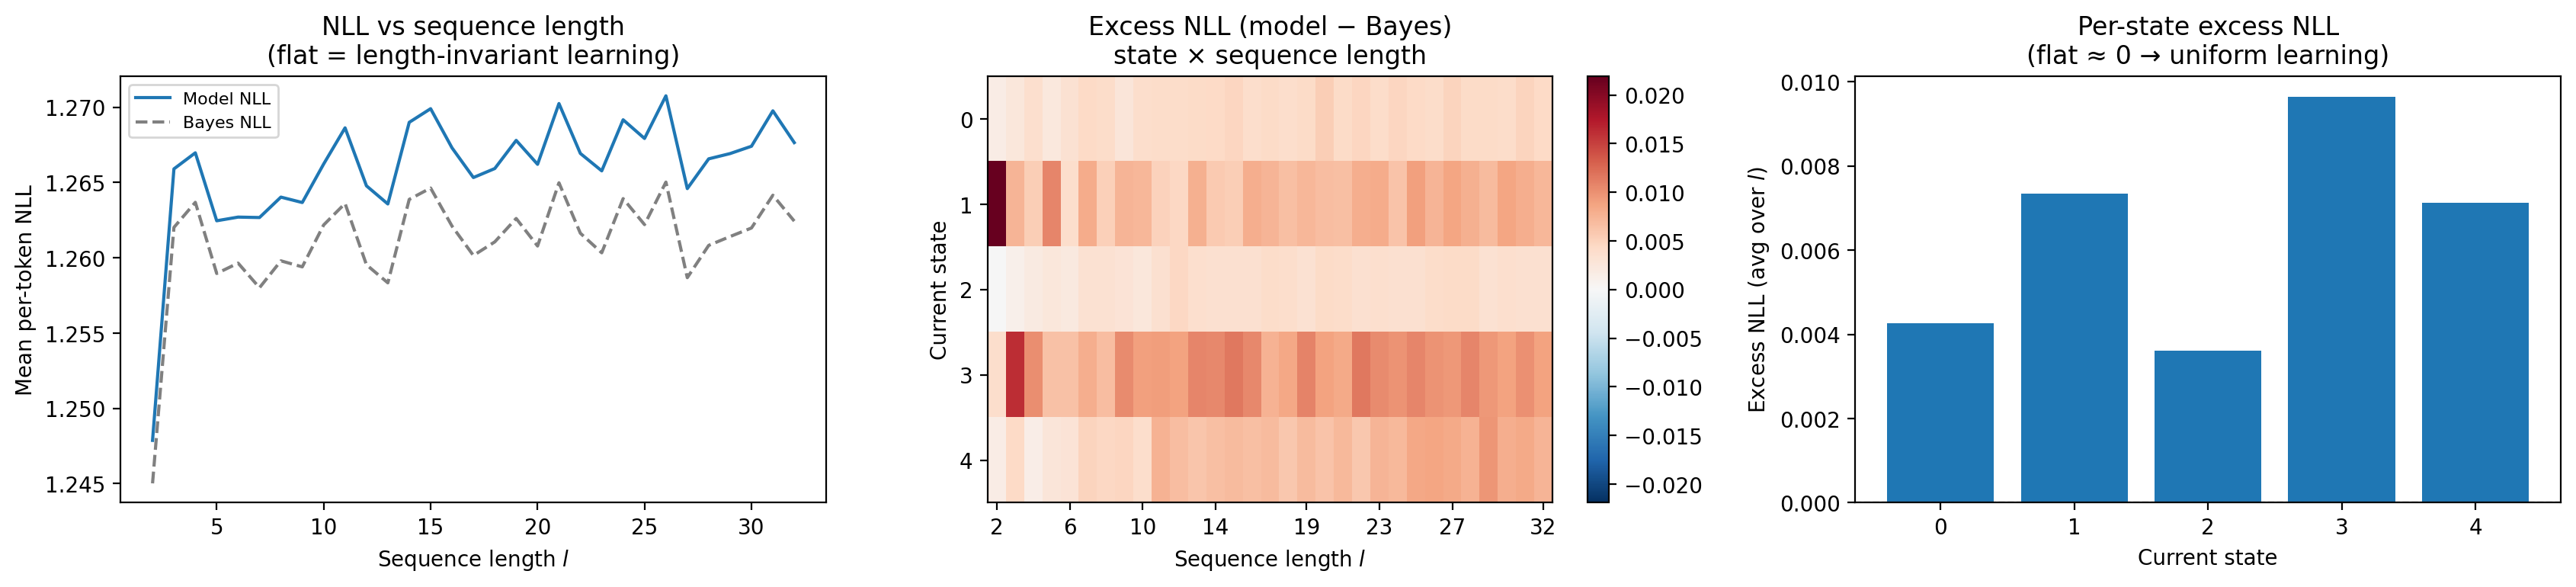

In [5]:
import numpy as np
from markov_chain import sample_sequences

max_len = int(data_cfg.get("seq_len", cfg.get("max_seq_len", 32)))
N_TEST = 250_000

# Draw sequence lengths i.i.d. from Uniform{2, ..., max_len}
rng_np = np.random.default_rng(42)
lengths = rng_np.integers(low=2, high=max_len + 1, size=N_TEST)  # (N,)

# Sample all sequences at max_len; the causal model means logits at position t
# only depend on x[0..t], so tokens beyond lengths[i]-1 are never "seen".
test_seqs_np = sample_sequences(
    T_reference.numpy(),
    n=N_TEST,
    seq_len=max_len,
    prior=pi_reference.numpy(),
    rng=42,
)
test_seqs = torch.from_numpy(test_seqs_np).long()  # (N, max_len)

x_in = test_seqs[:, :-1]  # (N, max_len-1)  context tokens
x_tgt = test_seqs[:, 1:]  # (N, max_len-1)  target tokens

# Position t (0-indexed) is valid for sequence i iff t+1 < lengths[i]
lengths_t = torch.from_numpy(lengths)
valid = torch.arange(max_len - 1) < (lengths_t.unsqueeze(1) - 1)  # (N, max_len-1)

# ── Model log-probs (full causal forward pass, then select valid entries) ─────
BATCH = 512
log_probs_model = torch.zeros(N_TEST, max_len - 1)
with torch.no_grad():
    for start in range(0, N_TEST, BATCH):
        logits = model(x_in[start : start + BATCH])
        lp = torch.log_softmax(logits, dim=-1)
        tgt = x_tgt[start : start + BATCH]
        log_probs_model[start : start + BATCH] = lp.gather(
            -1, tgt.unsqueeze(-1)
        ).squeeze(-1)

log_T = torch.log(T_reference.clamp_min(1e-12))
log_probs_bayes = log_T[x_in, x_tgt]  # (N, max_len-1)

# ── Flatten to per-observation arrays (only valid positions) ──────────────────
valid_np = valid.numpy()
flat_lpm = log_probs_model.numpy()[valid_np]  # model log-prob
flat_lpb = log_probs_bayes.float().numpy()[valid_np]  # Bayes log-prob
flat_state = x_in.numpy()[valid_np]  # current state
# sequence length for each observation
lengths_grid = np.tile(lengths[:, None], (1, max_len - 1))  # (N, max_len-1)
flat_len = lengths_grid[valid_np]  # in {2..max_len}

len_vals = np.arange(2, max_len + 1)

# ── 1. NLL vs sequence length ─────────────────────────────────────────────────
nll_model_by_l = np.array(
    [
        -flat_lpm[flat_len == l].mean() if (flat_len == l).any() else np.nan
        for l in len_vals
    ]
)
nll_bayes_by_l = np.array(
    [
        -flat_lpb[flat_len == l].mean() if (flat_len == l).any() else np.nan
        for l in len_vals
    ]
)

# ── 2. Per-(state, length) excess NLL heatmap ─────────────────────────────────
nll_st_model = np.full((VOCAB, len(len_vals)), np.nan)
nll_st_bayes = np.full((VOCAB, len(len_vals)), np.nan)

for li, l in enumerate(len_vals):
    mask_l = flat_len == l
    for s in range(VOCAB):
        mask_sl = mask_l & (flat_state == s)
        if mask_sl.any():
            nll_st_model[s, li] = -flat_lpm[mask_sl].mean()
            nll_st_bayes[s, li] = -flat_lpb[mask_sl].mean()

excess_st = nll_st_model - nll_st_bayes  # (VOCAB, len(len_vals))

# ── 3. Per-state excess, marginalising over length ────────────────────────────
excess_by_s = np.array(
    [
        -flat_lpm[flat_state == s].mean() + flat_lpb[flat_state == s].mean()
        if (flat_state == s).any()
        else np.nan
        for s in range(VOCAB)
    ]
)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Panel 1 — NLL vs sequence length
axes[0].plot(len_vals, nll_model_by_l, label="Model NLL")
axes[0].plot(len_vals, nll_bayes_by_l, linestyle="--", color="gray", label="Bayes NLL")
axes[0].set_xlabel("Sequence length $l$")
axes[0].set_ylabel("Mean per-token NLL")
axes[0].set_title("NLL vs sequence length\n(flat = length-invariant learning)")
axes[0].legend(fontsize=8)

# Panel 2 — Excess NLL heatmap (state × length)
vmax = float(np.nanmax(np.abs(excess_st))) or 1.0
tick_idx = np.linspace(0, len(len_vals) - 1, min(8, len(len_vals)), dtype=int)
im = axes[1].imshow(excess_st, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_xticks(tick_idx)
axes[1].set_xticklabels(len_vals[tick_idx])
axes[1].set_yticks(range(VOCAB))
axes[1].set_xlabel("Sequence length $l$")
axes[1].set_ylabel("Current state")
axes[1].set_title("Excess NLL (model − Bayes)\nstate × sequence length")
plt.colorbar(im, ax=axes[1])

# Panel 3 — Per-state excess, length marginalised
axes[2].bar(range(VOCAB), excess_by_s)
axes[2].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[2].set_xticks(range(VOCAB))
axes[2].set_xlabel("Current state")
axes[2].set_ylabel("Excess NLL (avg over $l$)")
axes[2].set_title("Per-state excess NLL\n(flat ≈ 0 → uniform learning)")

plt.tight_layout()
plt.show()

## Hessian curvature vs sample size

This section loads the sample-size sweep checkpoints from `04_training.ipynb`
(`sample_size_models/checkpoint_N_*.pt`) and computes the Hessian at each
sample-size MAP. The goal is to see how the MAP moves with increasing data, how
Hessian degeneracy evolves, and how the local profile-likelihood surface changes
with sample size.


In [6]:
# Population-KL profile setup.
#
# The object we profile is the POPULATION KL between the true chain q and the model:
#     F(w) = E_{x~q}[ log q(x) - log p(x|w) ] = KL(q || p_w)
#          ≈ (1/M) Σ_m [ log q(x_m) - log p(x_m|w) ],   x_m ~ q   (Monte-Carlo, M large)
# Since q is the analytic Gambler's-Ruin chain, log q is exact and E_q[-log q] = H is a
# constant, so  F(w) = mean-NLL(w on the M sample) - H.
#
# Profiling (NOT slicing): at each (alpha, beta) grid point we FIX two parameters and
# MINIMIZE F over all the other parameters, then plot the resulting KL. Slicing (freezing
# the rest) would show a different, steeper surface; we want the profile, where the rest of
# the network re-adapts. We view the KL level sets for chosen PARAMETER PAIRS to diagnose
# sampling. A flat / compensated level set is itself an informative diagnostic.
#
# Why population KL (not the in-sample loss): KL >= 0 has a finite minimizer, so the
# constrained minimization is well-posed. Minimizing the in-sample empirical loss instead
# lets an over-parameterized model send ||theta||->inf (loss -> -inf), which never
# converges. M=3000 draws is within ~0.005 nat (optimizer noise) of much larger M.
#
# Minimizer: MINIBATCH SGD (Adam, batch 256 = training scale) with cosine LR decay; the
# minibatch noise self-regularizes ||theta||. Each cell value is the mean full-data F over
# the late iterates. Axes = two parameters with the largest Hessian diagonal curvature.
from markov_chain import sample_sequences
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.utils.data import DataLoader, TensorDataset
from torch_bdn.bn import fit_constrained, top_diagonal_curvature_indices
from torch_bdn.bn.bayesian_net import approx_hessian

SEED = 42
M_KL = 3000  # Monte-Carlo draws from q for the population-KL estimate
KL_BATCH = 256  # minibatch size (matches 04 training scale; noise self-regularizes)
KL_LR = 3e-3  # SGD/Adam learning rate (matches 04)
ANCHOR_EPOCHS = 300  # epochs to descend the population-KL minimizer w*

MAX_LEN = int(data_cfg.get("L", data_cfg.get("seq_len", cfg.get("max_len", 10))))

# ── Monte-Carlo sample from the TRUE chain q (the integral approximation) ──
_kl_seqs = torch.from_numpy(
    sample_sequences(
        T_reference.numpy(),
        n=M_KL,
        seq_len=MAX_LEN,
        prior=pi_reference.numpy(),
        rng=777,
    )
).long()
X_KL = _kl_seqs[:, :-1].clone()
Y_KL = _kl_seqs[:, 1:].clone()
X_KL[X_KL == PAD_ID] = 0
KL_DS = TensorDataset(X_KL, Y_KL)

# Entropy floor H = E_q[-log q]: KL = mean-NLL - H_FLOOR.
_logT = torch.log(T_reference.clamp_min(1e-12))
H_FLOOR = float(-(pi_reference[:, None] * T_reference * _logT).sum().item())


def loss_fn(logits, targets):
    """Mean per-token NLL ignoring PAD (CrossEntropy, mean reduction). On the M-sample
    this is the Monte-Carlo estimate of E_q[-log p(x|w)]; subtract H_FLOOR for the KL."""
    return F.cross_entropy(
        logits.reshape(-1, VOCAB),
        targets.reshape(-1),
        reduction="mean",
        ignore_index=PAD_ID,
    )


def kl_batches():
    """One epoch of minibatches over the M-sample (deterministic shuffle = training-like)."""
    g = torch.Generator().manual_seed(SEED)
    return DataLoader(KL_DS, batch_size=KL_BATCH, shuffle=True, generator=g)


def population_kl(model):
    with torch.no_grad():
        return loss_fn(model(X_KL), Y_KL).item() - H_FLOOR


# ── Find the population-KL minimizer w* (the anchor / star), via minibatch SGD ──
# Start from the largest-N checkpoint purely as an init; w* is defined by minimizing F.
_anchor_ckpt = torch.load(
    sample_size_model_dir / f"checkpoint_N_{int(_ref_rec['N'])}.pt", weights_only=False
)
wstar_model = MarkovTransformer(**_anchor_ckpt["config"])
wstar_model.load_state_dict(_anchor_ckpt["model_state"])

_anchor_res = fit_constrained(
    wstar_model,
    loss_fn,
    kl_batches,
    fixed_indices=torch.tensor([], dtype=torch.long),
    epochs=ANCHOR_EPOCHS,
    lr=KL_LR,
    full_data=(X_KL, Y_KL),
    restore=False,
)
theta_star = _anchor_res.theta
vector_to_parameters(theta_star, wstar_model.parameters())
wstar_model.eval()

# Hessian of F at w* -> choose the two PARAMETERS with the largest diagonal curvature as
# the profile axes (raw single weights, so the level sets are per-parameter-pair).
H_star = approx_hessian(wstar_model, loss_fn, X_KL, Y_KL, chunk_size=4096)
AXIS_I, AXIS_J = [int(t) for t in top_diagonal_curvature_indices(H_star, 2)]
_eig = torch.linalg.eigvalsh(H_star)

print(
    f"Population-KL minimizer w*: KL={population_kl(wstar_model):.4f} "
    f"(mean-NLL={_anchor_res.loss:.4f}, H_floor={H_FLOOR:.4f}), ||theta||={theta_star.norm():.2f}, "
    f"|free_grad|={_anchor_res.free_grad_norm:.1e}"
)
print(
    f"Hessian(F) eig range [{_eig[0]:.2e}, {_eig[-1]:.2e}]; "
    f"profile axes = params {AXIS_I},{AXIS_J} (diag curv {H_star[AXIS_I, AXIS_I]:.3f}, {H_star[AXIS_J, AXIS_J]:.3f})"
)

Population-KL minimizer w*: KL=-0.0035 (mean-NLL=1.2581, H_floor=1.2616), ||theta||=14.27, |free_grad|=1.3e-02
Hessian(F) eig range [-1.20e-02, 2.45e+00]; profile axes = params 12,27 (diag curv 0.259, 0.255)


In [7]:
# Sample-size Hessian sweep (separate from the population-KL profile below).
#
# This characterizes how the EMPIRICAL (in-sample) loss curvature at each trained
# checkpoint evolves with sample size N — Hessian degeneracy, extreme eigenvalues,
# condition number. It is a different object from the population-KL profile (which uses
# w* and the M-sample); here each N uses its own checkpoint and its own N sequences.
#
# NOTE: these per-N checkpoints are early-stopped MLEs of the *unregularized* NLL, so the
# Hessian is taken at a non-stationary, highly degenerate point — the large negative/flat
# eigenvalue counts below are the singular geometry of that in-sample loss, not a bug.
sample_size_records = sorted(
    torch.load(DATA_DIR / "sample_size_sweep.pt", weights_only=False),
    key=lambda r: int(r["N"]),
)
ALL_SEQUENCES = seqs.long()


def _subset(N):
    rng = torch.Generator().manual_seed(SEED + N)
    idx = torch.randperm(ALL_SEQUENCES.shape[0], generator=rng)[:N]
    s = ALL_SEQUENCES[idx]
    x = s[:, :-1].clone()
    y = s[:, 1:].clone()
    x[x == PAD_ID] = 0
    return x, y


sample_size_results = []
for rec in sample_size_records:
    N = int(rec["N"])
    ckpt_n = torch.load(
        sample_size_model_dir / f"checkpoint_N_{N}.pt", weights_only=False
    )
    m_n = MarkovTransformer(**ckpt_n["config"])
    m_n.load_state_dict(ckpt_n["model_state"])
    m_n.eval()
    x_n, y_n = _subset(N)
    H = approx_hessian(m_n, loss_fn, x_n, y_n, chunk_size=10240)
    eigvals = torch.linalg.eigvalsh(H).cpu()
    max_eig = float(eigvals[-1].item())
    threshold = max(1e-12, max_eig * 1e-6)
    sample_size_results.append(
        {
            "N": N,
            "record": rec,
            "eigvals": eigvals,
            "flat_count": int((eigvals <= threshold).sum().item()),
            "negative_count": int((eigvals < 0).sum().item()),
            "condition_number": float(
                abs(eigvals[-1].item()) / max(abs(eigvals[0].item()), 1e-16)
            ),
        }
    )
    print(
        f"N={N}: min={eigvals[0]:.2e}, max={eigvals[-1]:.2e}, "
        f"neg={sample_size_results[-1]['negative_count']}, "
        f"flat={sample_size_results[-1]['flat_count']}"
    )

N=50: min=-1.19e-01, max=5.45e+00, neg=447, flat=600


N=80: min=-5.45e-02, max=7.32e+00, neg=434, flat=581


N=130: min=-5.23e-02, max=5.06e+00, neg=434, flat=584


N=200: min=-6.21e-02, max=3.89e+00, neg=433, flat=581


N=320: min=-8.96e-02, max=4.82e+00, neg=436, flat=604


N=520: min=-3.71e-02, max=6.62e+00, neg=436, flat=596


N=840: min=-2.74e-02, max=9.45e+00, neg=423, flat=580


N=1350: min=-1.52e-02, max=3.93e+00, neg=425, flat=577


N=2150: min=-2.69e-02, max=6.12e+00, neg=434, flat=617


N=3000: min=-1.18e-02, max=3.61e+00, neg=421, flat=575


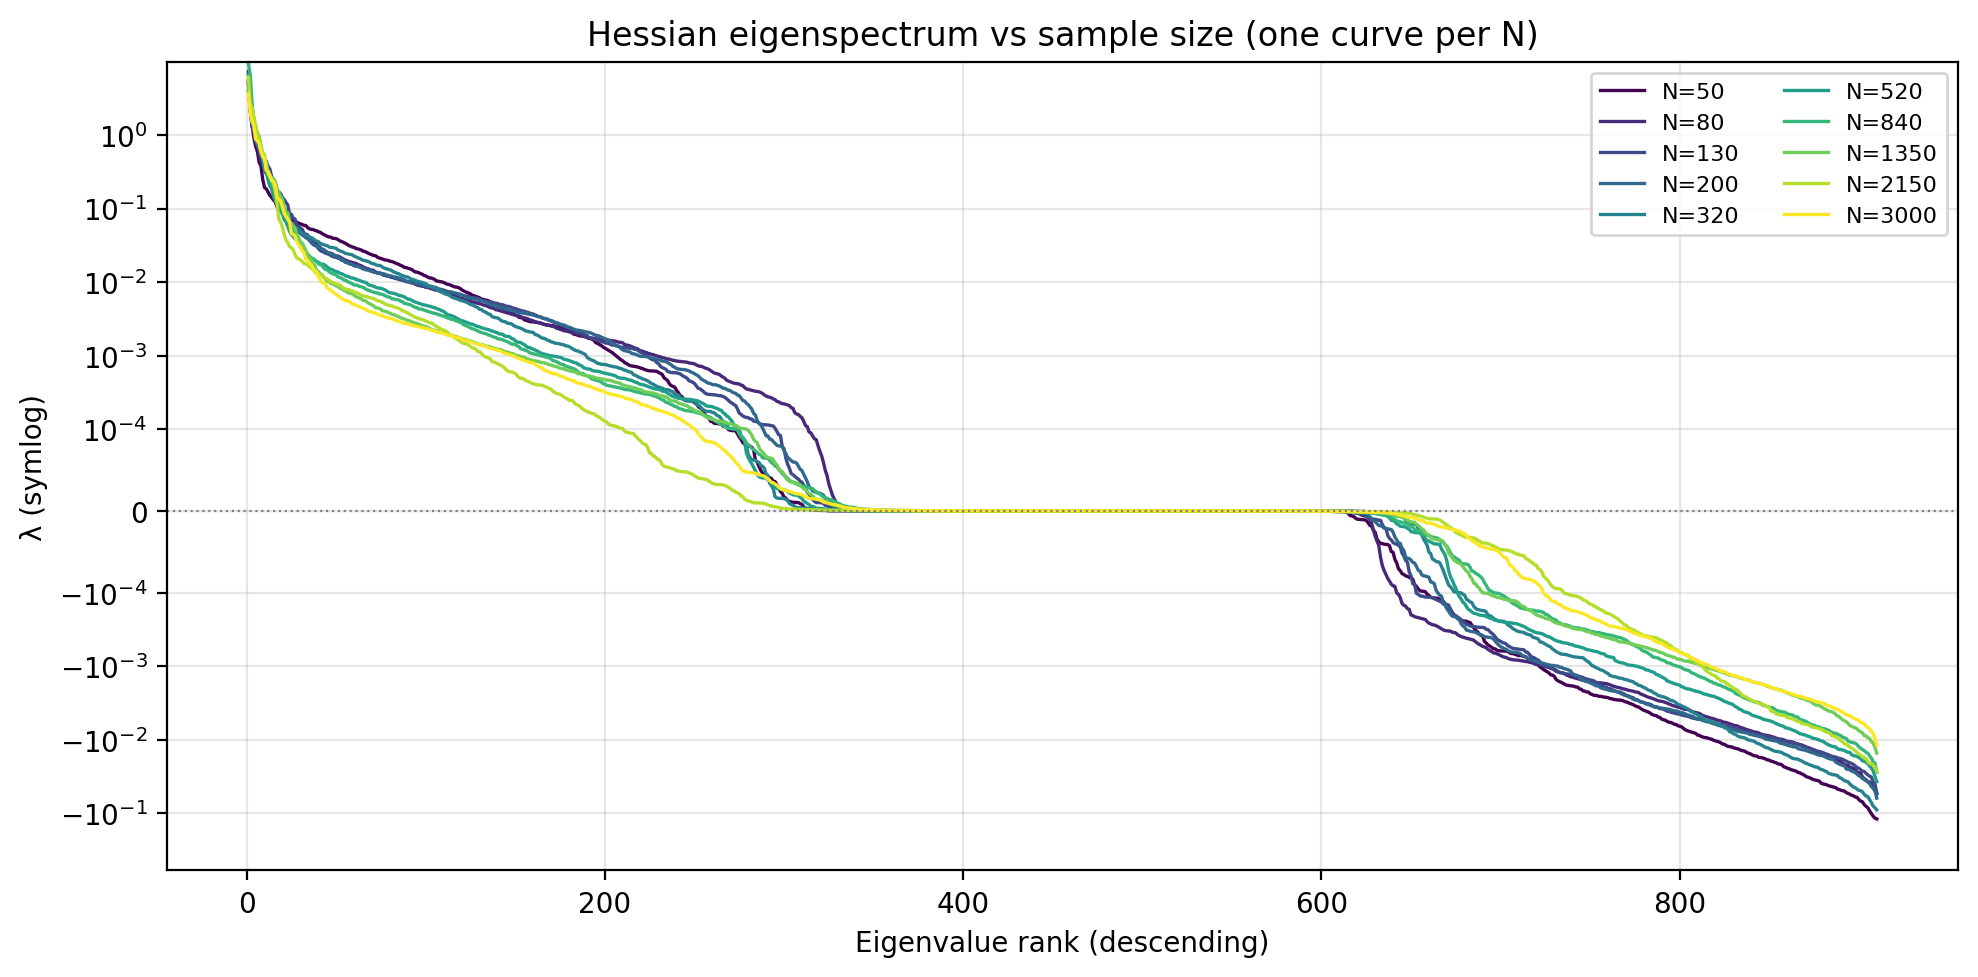

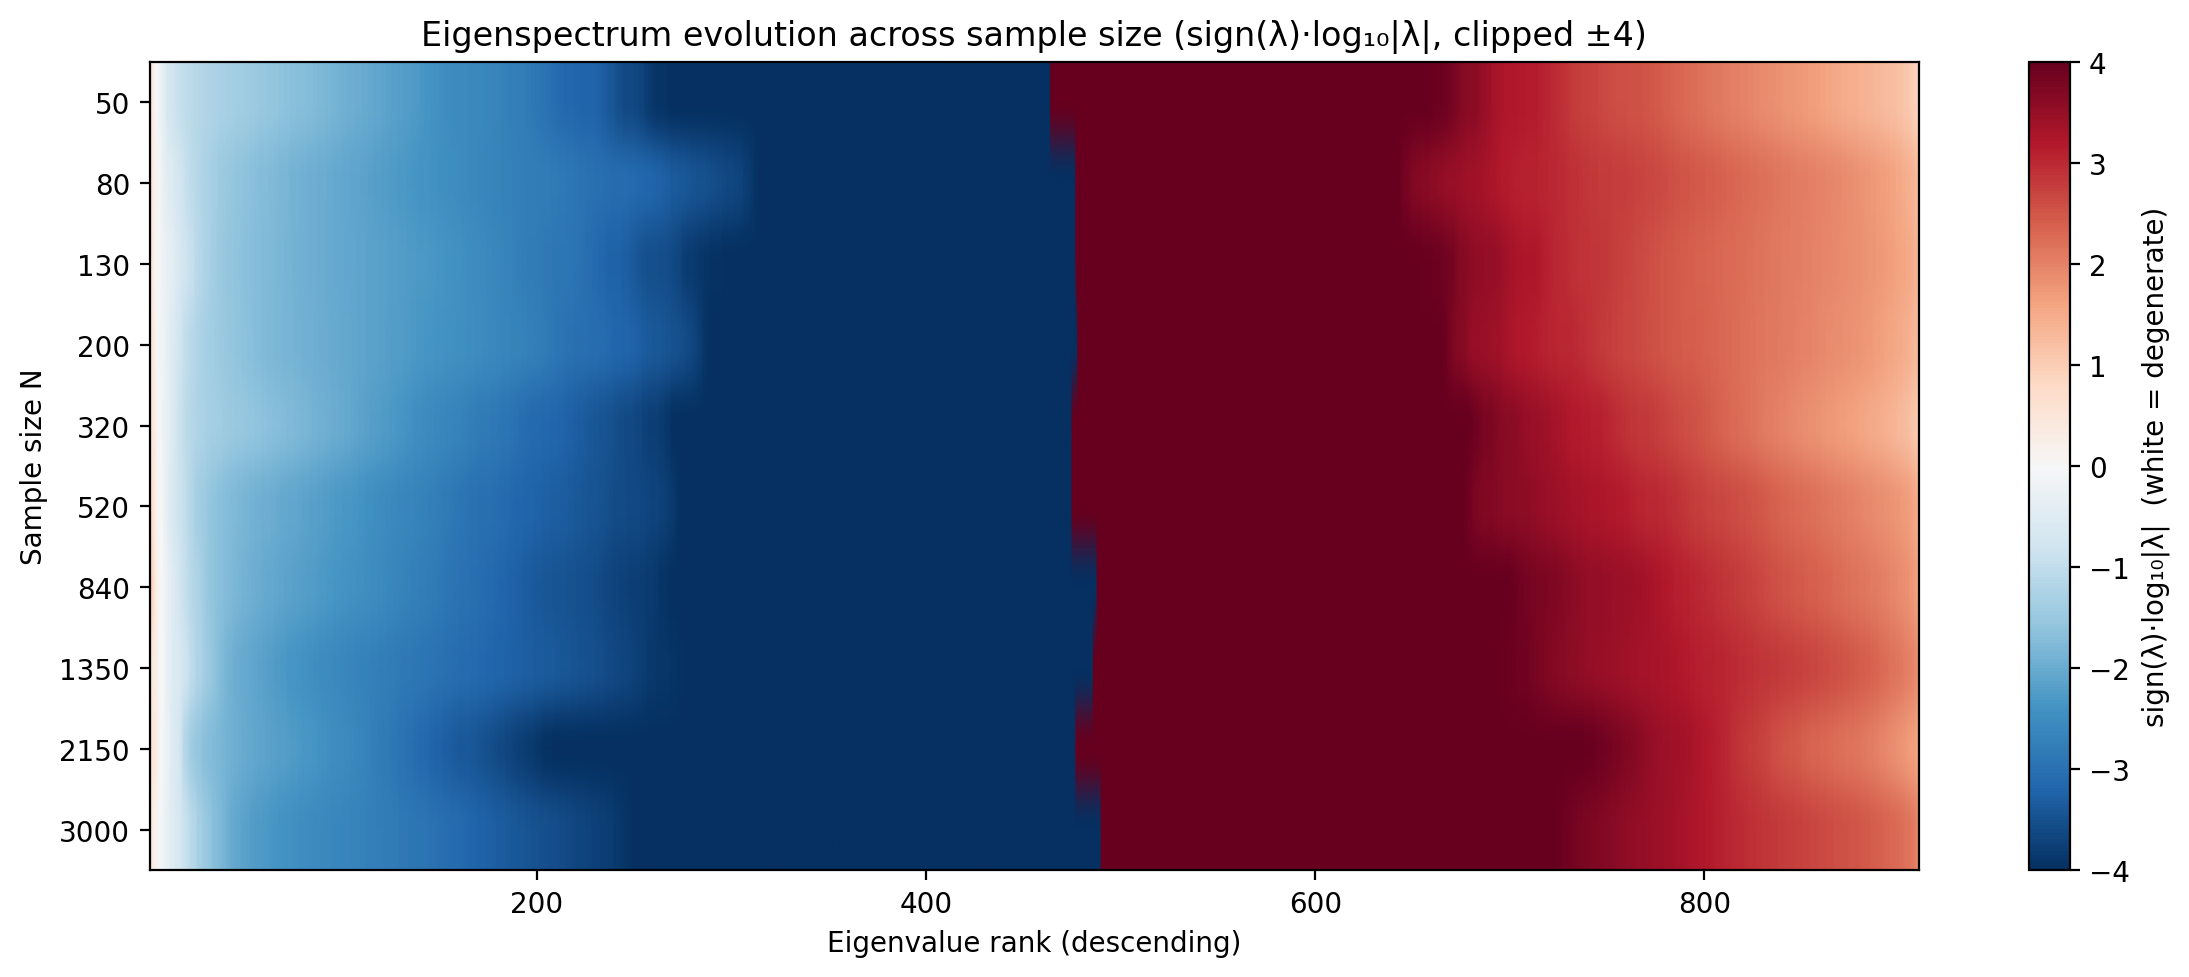

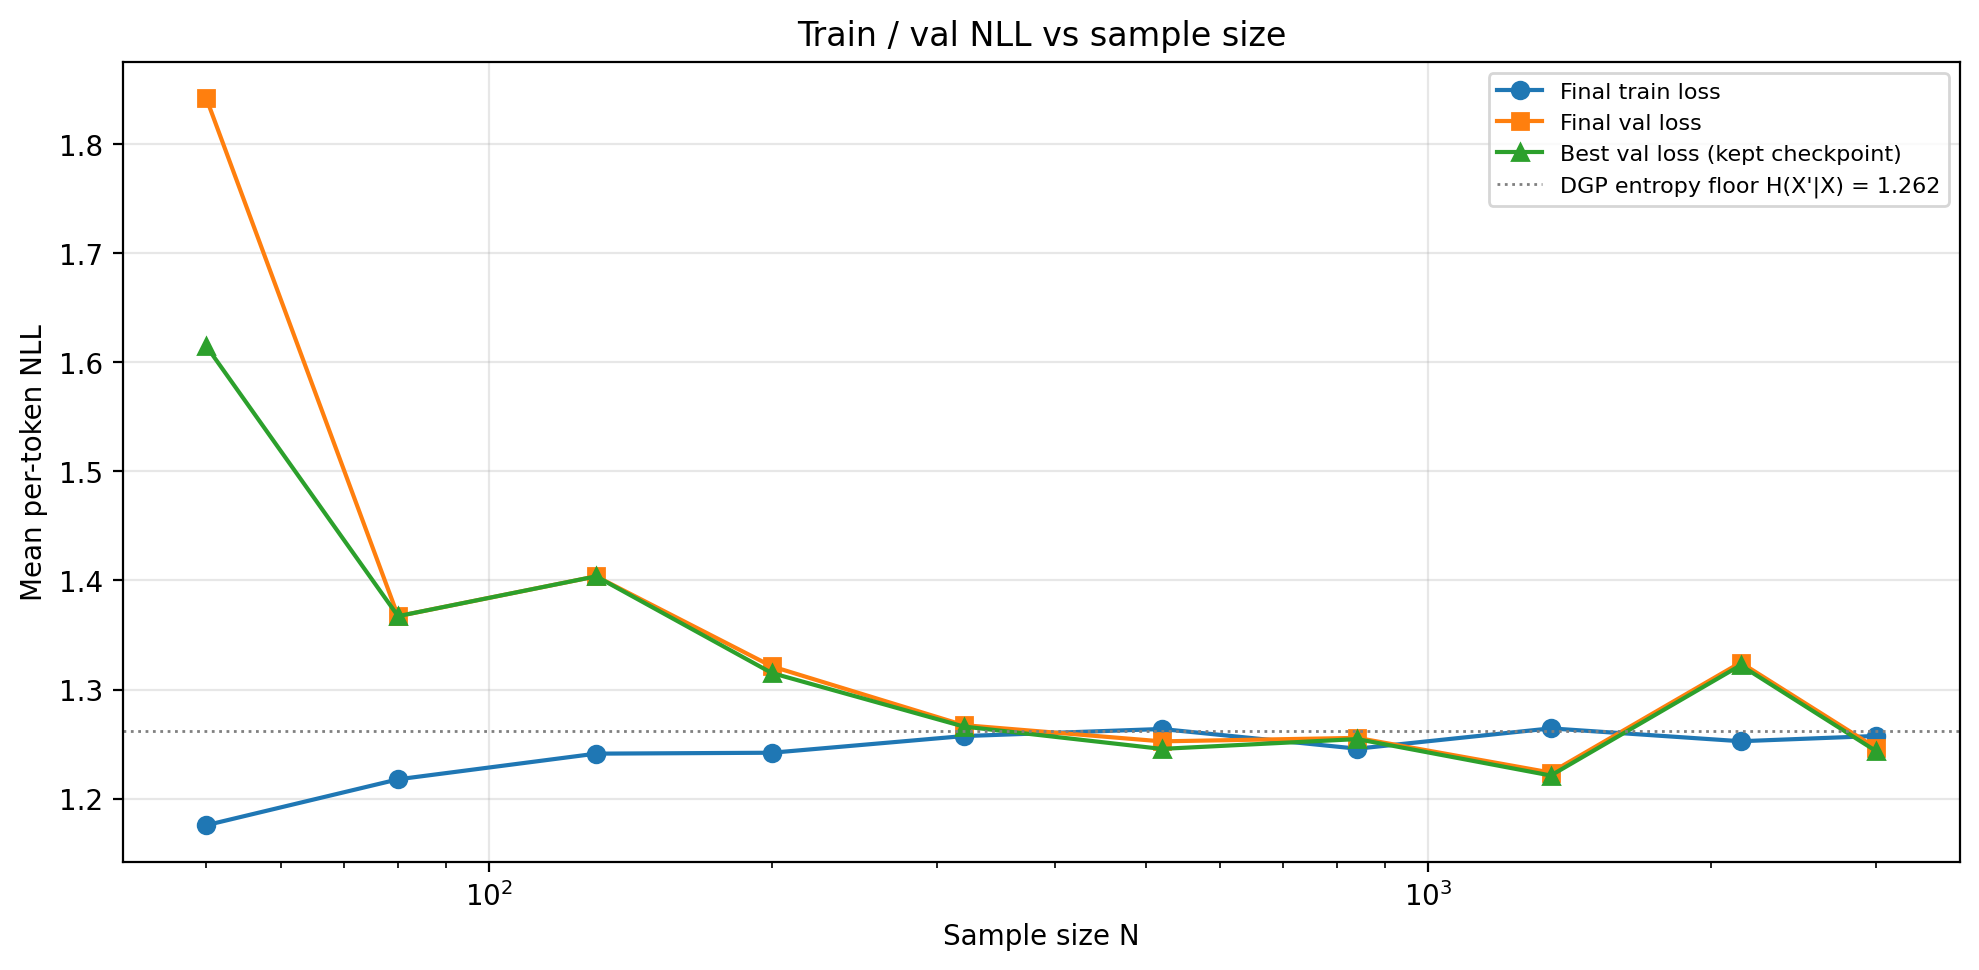

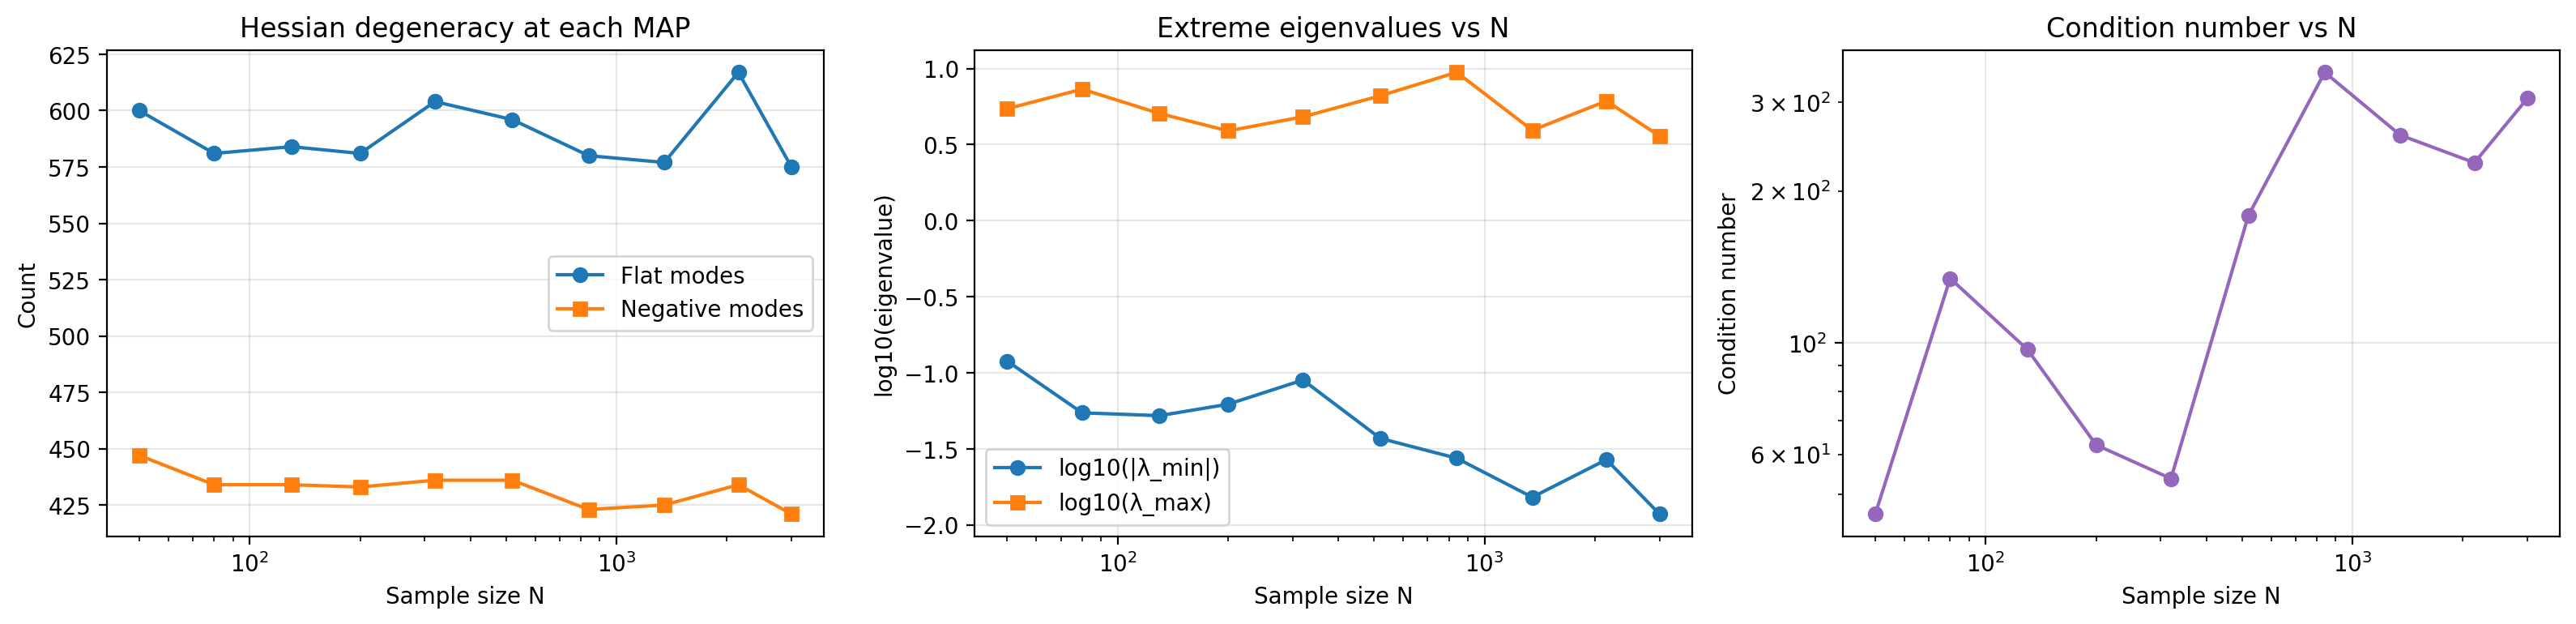

In [8]:
# ── Eigenspectrum evolution ACROSS sample size ──
# One Hessian per N (computed above). Show how the full spectrum changes with N.
Ns = [r["N"] for r in sample_size_results]
final_train = [r["record"]["final_train_loss"] for r in sample_size_results]
final_val = [r["record"]["final_val_loss"] for r in sample_size_results]
best_val = [r["record"]["best_val_loss"] for r in sample_size_results]
flat_counts = [r["flat_count"] for r in sample_size_results]
negative_counts = [r["negative_count"] for r in sample_size_results]
condition_numbers = [r["condition_number"] for r in sample_size_results]
min_eigs = [r["eigvals"][0].item() for r in sample_size_results]
max_eigs = [r["eigvals"][-1].item() for r in sample_size_results]

# DGP conditional entropy H(X'|X): irreducible per-token CE floor (loss → this, not 0).
_logT = torch.log(T_reference.clamp_min(1e-12))
cond_entropy = float(-(pi_reference[:, None] * T_reference * _logT).sum().item())

# (1) Full sorted spectrum overlaid, one curve per N.
eig_sorted = torch.stack(
    [torch.sort(r["eigvals"], descending=True).values for r in sample_size_results]
)  # (n_N, d)
ranks = np.arange(1, eig_sorted.shape[1] + 1)

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(Ns)))
for i, N in enumerate(Ns):
    ax.plot(ranks, eig_sorted[i].numpy(), color=cmap[i], lw=1.2, label=f"N={N}")
ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.set_yscale("symlog", linthresh=1e-4)
ax.set_xlabel("Eigenvalue rank (descending)")
ax.set_ylabel("λ (symlog)")
ax.set_title("Hessian eigenspectrum vs sample size (one curve per N)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (2) Heatmap: sample size × eigenvalue rank, colored by sign(λ)·log10|λ|.
signed_log = torch.sign(eig_sorted) * torch.log10(eig_sorted.abs() + 1e-12)
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    signed_log.numpy(),
    aspect="auto",
    cmap="RdBu_r",
    origin="upper",
    vmin=-4.0,
    vmax=4.0,
    extent=[1, eig_sorted.shape[1], len(Ns) - 0.5, -0.5],
)
ax.set_yticks(range(len(Ns)))
ax.set_yticklabels(Ns)
ax.set_xlabel("Eigenvalue rank (descending)")
ax.set_ylabel("Sample size N")
ax.set_title(
    "Eigenspectrum evolution across sample size (sign(λ)·log₁₀|λ|, clipped ±4)"
)
plt.colorbar(im, ax=ax, label="sign(λ)·log₁₀|λ|  (white = degenerate)")
plt.tight_layout()
plt.show()

# (3) Learning curves vs N (loss converges to the entropy floor, not 0).
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(Ns, final_train, marker="o", label="Final train loss")
ax.semilogx(Ns, final_val, marker="s", label="Final val loss")
ax.semilogx(Ns, best_val, marker="^", label="Best val loss (kept checkpoint)")
ax.axhline(
    cond_entropy,
    color="gray",
    ls=":",
    lw=1.0,
    label=f"DGP entropy floor H(X'|X) = {cond_entropy:.3f}",
)
ax.set_xlabel("Sample size N")
ax.set_ylabel("Mean per-token NLL")
ax.set_title("Train / val NLL vs sample size")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# (4) Degeneracy / extreme eigenvalues / condition number vs N.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].semilogx(Ns, flat_counts, marker="o", label="Flat modes")
axes[0].semilogx(Ns, negative_counts, marker="s", label="Negative modes")
axes[0].set_xlabel("Sample size N")
axes[0].set_ylabel("Count")
axes[0].set_title("Hessian degeneracy at each MAP")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(
    Ns, np.log10(np.abs(min_eigs) + 1e-20), marker="o", label="log10(|λ_min|)"
)
axes[1].semilogx(Ns, np.log10(max_eigs), marker="s", label="log10(λ_max)")
axes[1].set_xlabel("Sample size N")
axes[1].set_ylabel("log10(eigenvalue)")
axes[1].set_title("Extreme eigenvalues vs N")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].semilogx(Ns, condition_numbers, marker="o", color="tab:purple")
axes[2].set_xlabel("Sample size N")
axes[2].set_ylabel("Condition number")
axes[2].set_yscale("log")
axes[2].set_title("Condition number vs N")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Population-KL profile contours

We profile the **population KL** $F(w)=\mathbb{E}_{x\sim q}[\log q(x)-\log p(x\mid w)]=\mathrm{KL}(q\,\|\,p_w)$,
estimated by Monte-Carlo over $M$ fresh draws from the true chain $q$ (so $F=$ mean-NLL on
the $M$ sample $-\,H$, with $H=\mathbb{E}_q[-\log q]$ the analytic entropy floor).

These are **profile** surfaces, not slices: at each grid point we **fix two parameters** at
$(w^\*_i+\alpha,\ w^\*_j+\beta)$ and **re-minimize $F$ over all the other $\sim\!908$
parameters**, then read $F$ there. A slice (freezing the rest) would show a steeper, different
surface; the profile lets the rest of the network re-adapt, which is the level set we want for
diagnosing sampling. The two axes are the parameters with the largest **diagonal** curvature of
the Hessian of $F$ at the population-KL minimizer $w^\*$.

Key choices (see the setup cell for the why):
- The object is the **population KL**, bounded below by 0, so the constrained minimization is
  **well-posed** — unlike the in-sample empirical loss, which an over-parameterized model
  drives to $-\infty$ by sending $\lVert\theta\rVert\to\infty$.
- The inner minimizer is **minibatch SGD** (Adam, batch 256, cosine LR decay); the minibatch
  noise self-regularizes $\lVert\theta\rVert$. Each cell value is the **mean of $F$ over the
  late iterates**. Tiny negative values are optimizer noise ($\sim$0.005 nat), clipped to 0.
- Expect the profile to be **flat / compensated** along single-parameter axes: moving one
  weight and re-minimizing the rest, the other parameters absorb the change (the diagonal
  curvature is a *slice* quantity; the *profile* curvature is the Schur complement, which is
  much smaller for correlated weights). A flat level set is an informative diagnostic, not a bug.


row 1/15 (alpha=-2.00) done


row 2/15 (alpha=-1.71) done


row 3/15 (alpha=-1.43) done


row 4/15 (alpha=-1.14) done


row 5/15 (alpha=-0.86) done


...

row 11/15 (alpha=+0.86) done


row 12/15 (alpha=+1.14) done


row 13/15 (alpha=+1.43) done


row 14/15 (alpha=+1.71) done


row 15/15 (alpha=+2.00) done
KL surface: min=0.00000  p10=0.00000  median=0.00000  p90=0.00000  max=0.00000  (range 0.00000 nat)


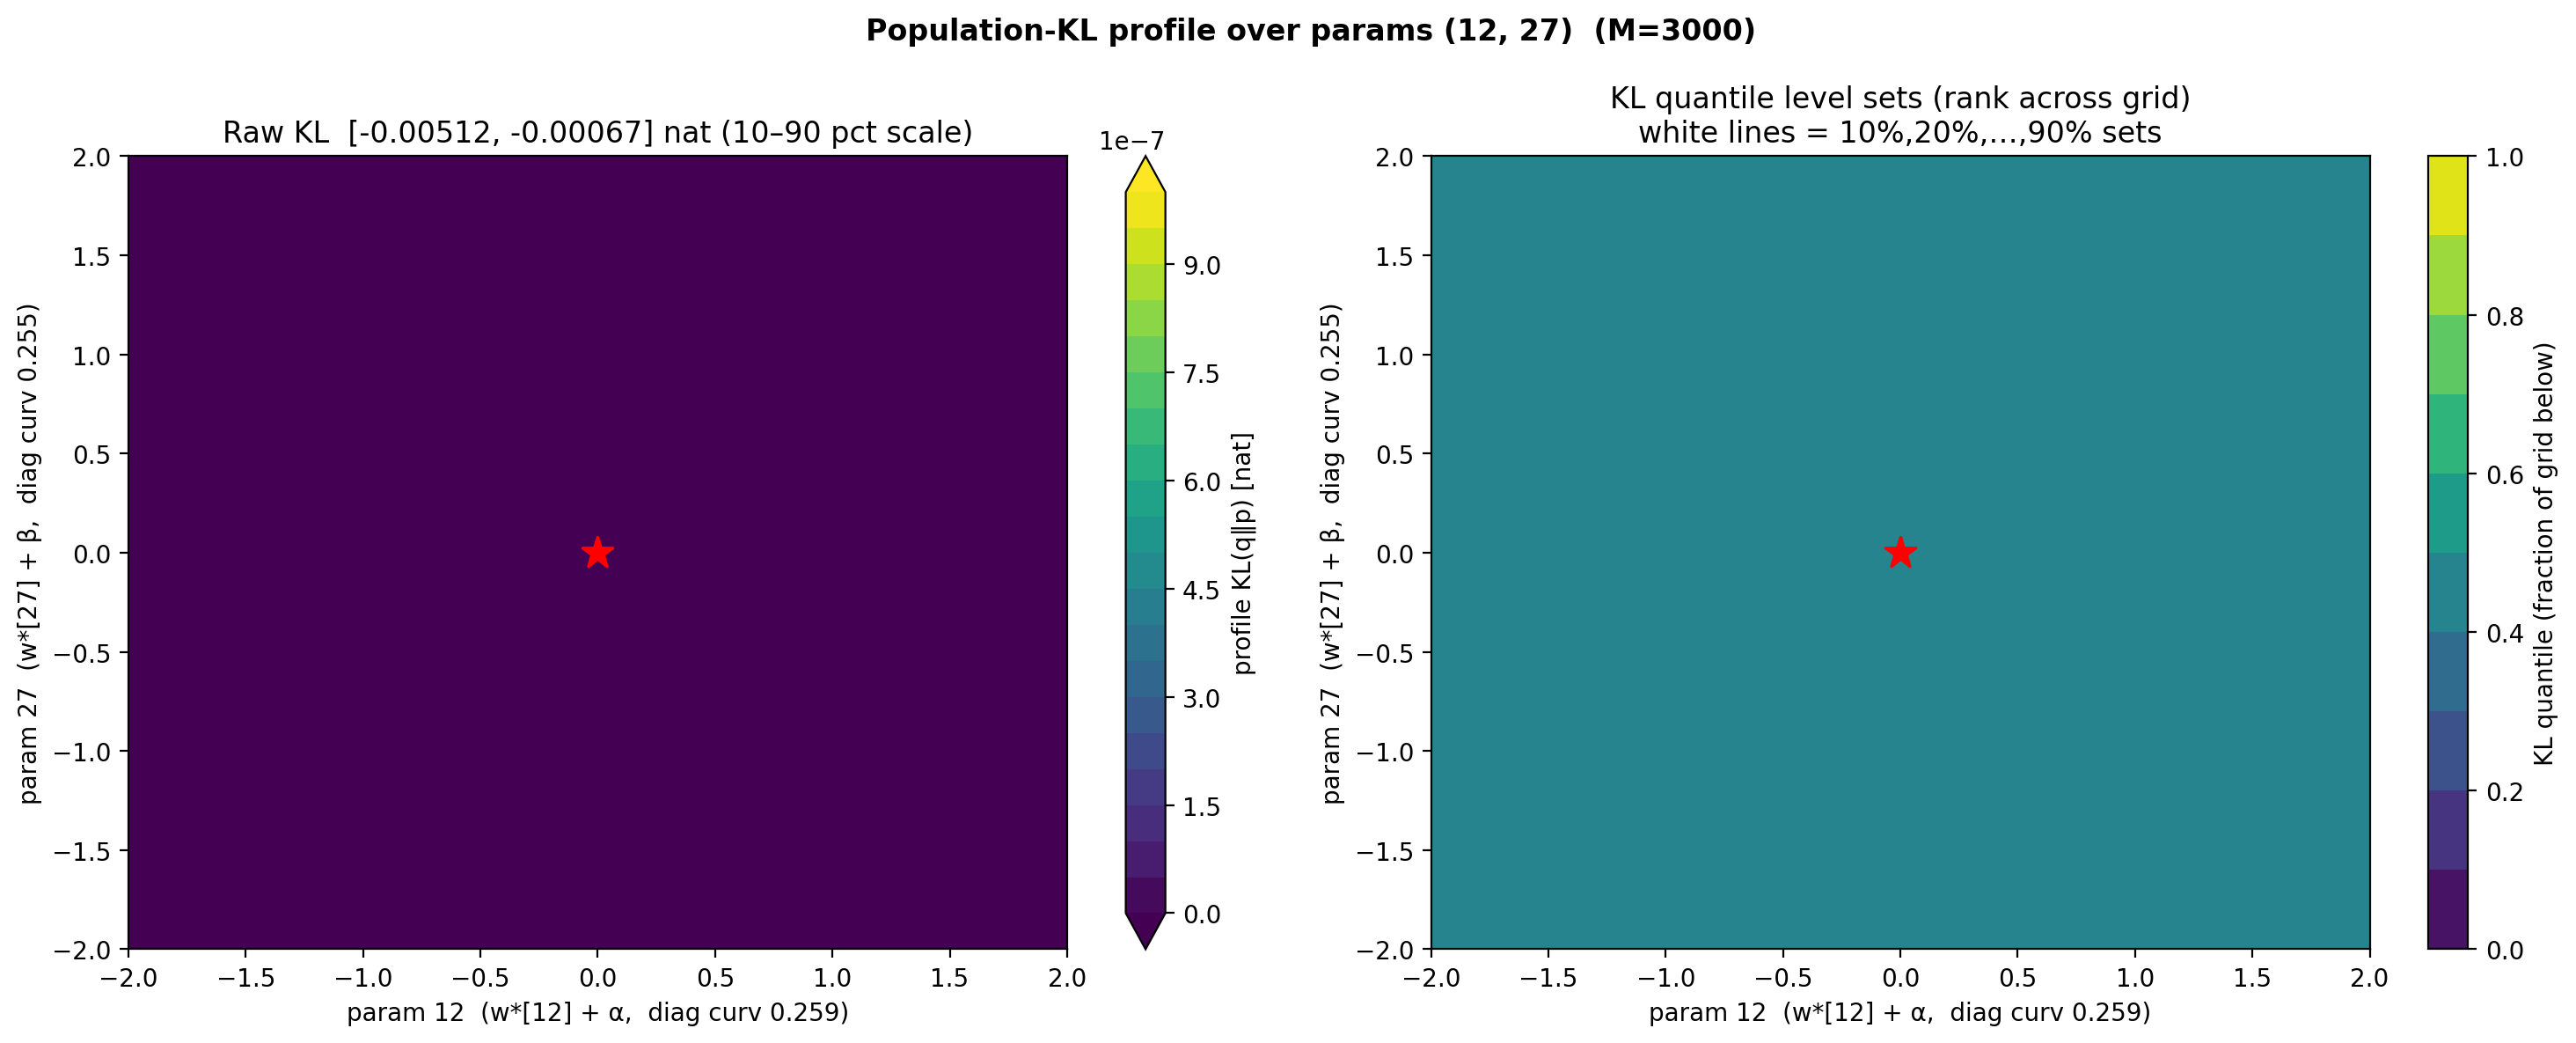

In [9]:
# Population-KL profile grid over the two parameter axes (AXIS_I, AXIS_J).
#
# At each (alpha, beta): pin w[AXIS_I]=w*[i]+alpha, w[AXIS_J]=w*[j]+beta and MINIMIZE F
# (population KL on the M-sample) over the OTHER ~908 parameters with minibatch SGD +
# cosine decay (this is the profile, not a slice — the rest of the net re-adapts). Read the
# cell value as the mean full-data KL over the late iterates. Warm-start across cells.
GRID = torch.linspace(-2.0, 2.0, 15)
GRID_NP = GRID.numpy()
CELL_EPOCHS = 60  # SGD epochs/cell; warm-started so this converges fast
CELL_AVG_FRAC = 0.3  # average full-data KL over the last 30% of epochs

FIXED = torch.tensor([AXIS_I, AXIS_J], dtype=torch.long)
_free_mask = torch.ones(theta_star.numel(), dtype=torch.bool)
_free_mask[FIXED] = False


def profile_cell(model, a, b, init_theta):
    """Pin params (AXIS_I, AXIS_J) at w*+(a, b); minimize F over the rest with minibatch
    SGD + cosine decay. Returns (late-iterate-averaged KL, final theta for warm-start)."""
    fixed_vals = torch.tensor([theta_star[AXIS_I] + a, theta_star[AXIS_J] + b])
    th = init_theta.clone()
    th[AXIS_I] = fixed_vals[0]
    th[AXIS_J] = fixed_vals[1]
    vector_to_parameters(th, model.parameters())
    opt = torch.optim.Adam(model.parameters(), lr=KL_LR)
    g = torch.Generator().manual_seed(SEED)
    avg_start = int(CELL_EPOCHS * (1.0 - CELL_AVG_FRAC))
    fs = []
    for ep in range(CELL_EPOCHS):
        for grp in opt.param_groups:
            grp["lr"] = 0.5 * KL_LR * (1.0 + float(np.cos(np.pi * ep / CELL_EPOCHS)))
        for xb, yb in DataLoader(KL_DS, batch_size=KL_BATCH, shuffle=True, generator=g):
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            # Freeze the two pinned parameters (zero their grad).
            off = 0
            for p in model.parameters():
                n = p.numel()
                msk = (~_free_mask[off : off + n]).view_as(p)
                if msk.any():
                    p.grad[msk] = 0.0
                off += n
            opt.step()
            with torch.no_grad():  # hard re-pin against drift
                cur = parameters_to_vector(model.parameters())
                cur[AXIS_I] = fixed_vals[0]
                cur[AXIS_J] = fixed_vals[1]
                vector_to_parameters(cur, model.parameters())
        if ep >= avg_start:
            fs.append(population_kl(model))
    return float(np.mean(fs)), parameters_to_vector(model.parameters()).detach().clone()


# Sweep the grid, warm-starting each cell from its row-neighbour (reset per row).
_grid_model = MarkovTransformer(**_anchor_ckpt["config"])
Z = np.zeros((len(GRID), len(GRID)))
for i, a in enumerate(GRID):
    warm = theta_star.clone()
    for j, b in enumerate(GRID):
        kl, warm = profile_cell(_grid_model, float(a), float(b), warm)
        Z[i, j] = kl
    print(f"row {i + 1}/{len(GRID)} (alpha={float(a):+.2f}) done")

# KL >= 0: clip tiny negative optimizer noise to 0 for display.
Z_disp = np.clip(Z, 0.0, None)
_q = np.percentile(Z_disp, [0, 10, 50, 90, 100])
print(
    f"KL surface: min={_q[0]:.5f}  p10={_q[1]:.5f}  median={_q[2]:.5f}  "
    f"p90={_q[3]:.5f}  max={_q[4]:.5f}  (range {_q[4] - _q[0]:.5f} nat)"
)

# QUANTILE-RANK map: replace each cell's raw KL by its empirical quantile in [0,1]
# across the grid. On a near-flat / log-scale surface the raw values are nearly
# identical, so ranks expose the LEVEL-SET SHAPE — where the 10%, 50%, 90% sets sit
# as we move away from w* — regardless of how tiny the absolute KL spread is.
from scipy.stats import rankdata

Zrank = (
    rankdata(Z_disp.ravel(), method="average").reshape(Z_disp.shape) - 0.5
) / Z_disp.size
decile_levels = np.linspace(0.0, 1.0, 11)  # 0,0.1,...,1.0 -> each band = 10% of cells

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: raw KL, colour scale from 10th–90th percentile.
vlo, vhi = float(_q[1]), float(_q[3])
if vhi <= vlo:
    vhi = vlo + 1e-6
raw_levels = np.linspace(vlo, vhi, 21)
cf0 = axes[0].contourf(
    GRID_NP, GRID_NP, Z_disp, levels=raw_levels, cmap="viridis", extend="both"
)
axes[0].contour(
    GRID_NP,
    GRID_NP,
    Z_disp,
    levels=raw_levels[::4],
    colors="white",
    linewidths=0.6,
    alpha=0.7,
)
axes[0].plot(0, 0, "r*", markersize=14)
axes[0].set_title(f"Raw KL  [{Z.min():.5f}, {Z.max():.5f}] nat (10–90 pct scale)")
fig.colorbar(cf0, ax=axes[0], label="profile KL(q‖p) [nat]")

# Right: quantile rank with decile level sets (10%, 20%, ..., 90%).
cf1 = axes[1].contourf(GRID_NP, GRID_NP, Zrank, levels=decile_levels, cmap="viridis")
cs = axes[1].contour(
    GRID_NP, GRID_NP, Zrank, levels=decile_levels[1:-1], colors="white", linewidths=0.8
)
axes[1].clabel(cs, fmt=lambda v: f"{round(v * 100)}%", fontsize=7)
axes[1].plot(0, 0, "r*", markersize=14)
axes[1].set_title(
    "KL quantile level sets (rank across grid)\nwhite lines = 10%,20%,…,90% sets"
)
fig.colorbar(cf1, ax=axes[1], label="KL quantile (fraction of grid below)")

for ax in axes:
    ax.set_xlabel(
        f"param {AXIS_I}  (w*[{AXIS_I}] + α,  diag curv {H_star[AXIS_I, AXIS_I]:.3f})"
    )
    ax.set_ylabel(
        f"param {AXIS_J}  (w*[{AXIS_J}] + β,  diag curv {H_star[AXIS_J, AXIS_J]:.3f})"
    )
fig.suptitle(
    f"Population-KL profile over params ({AXIS_I}, {AXIS_J})  (M={M_KL})",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [ ]:
# NLL SLICES: stiff vs sloppy directions, in BOTH the parameter basis and the eigenvector
# basis (all other directions fixed at w*).
#
# A SLICE (not the profile): fix everything except the 2 plotted directions at w*, vary
# those 2, evaluate KL = mean-NLL(M-sample) - H_FLOOR with one forward pass per cell. Cheap.
# 2x2 panels:
#   params  : stiff = 2 largest-|H_ii| weights,   sloppy = 2 smallest-|H_ii| weights
#   eigvecs : stiff = 2 largest-λ eigvecs,         sloppy = 2 smallest-λ eigvecs
# Expectation (singular geometry): stiff slices rise steeply, sloppy slices stay ~flat.
# (The PROFILE above is flat in ALL these directions — the other params compensate.)
SLICE_GRID = torch.linspace(-3.0, 3.0, 41)
_sg = SLICE_GRID.numpy()

_diag = torch.diagonal(H_star)
_stiff_params = torch.topk(_diag, 2).indices  # largest diagonal curvature
_sloppy_params = torch.topk(-_diag, 2).indices  # smallest diagonal curvature
D = theta_star.numel()


def _onehot(idx):
    e = torch.zeros(D)
    e[idx] = 1.0
    return e


# Each panel: (title, dir_u, dir_v, label_u, label_v). Directions are unit vectors in
# parameter space; for params they're one-hots, for eigvecs the (orthonormal) columns.
PANELS = [
    (
        "params (stiff)",
        _onehot(int(_stiff_params[0])),
        _onehot(int(_stiff_params[1])),
        f"param {int(_stiff_params[0])} (H_ii={_diag[_stiff_params[0]]:.3f})",
        f"param {int(_stiff_params[1])} (H_ii={_diag[_stiff_params[1]]:.3f})",
    ),
    (
        "params (sloppy)",
        _onehot(int(_sloppy_params[0])),
        _onehot(int(_sloppy_params[1])),
        f"param {int(_sloppy_params[0])} (H_ii={_diag[_sloppy_params[0]]:.1e})",
        f"param {int(_sloppy_params[1])} (H_ii={_diag[_sloppy_params[1]]:.1e})",
    ),
    (
        "eigvecs (stiff)",
        _evecs[:, -1],
        _evecs[:, -2],
        f"eigvec λ={_evals[-1]:.2f}",
        f"eigvec λ={_evals[-2]:.2f}",
    ),
    (
        "eigvecs (sloppy)",
        _evecs[:, 0],
        _evecs[:, 1],
        f"eigvec λ={_evals[0]:.1e}",
        f"eigvec λ={_evals[1]:.1e}",
    ),
]


def slice_grid(u, v):
    u = u / u.norm()
    v = v / v.norm()
    Z = np.zeros((len(SLICE_GRID), len(SLICE_GRID)))
    with torch.no_grad():
        for ia, a in enumerate(SLICE_GRID):
            for jb, b in enumerate(SLICE_GRID):
                vector_to_parameters(
                    theta_star + a * u + b * v, wstar_model.parameters()
                )
                Z[ia, jb] = loss_fn(wstar_model(X_KL), Y_KL).item() - H_FLOOR
    return Z


fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (title, u, v, lx, ly) in zip(axes.ravel(), PANELS):
    Z = slice_grid(u, v)
    vmax = float(np.percentile(Z, 99))
    levels = np.linspace(0.0, vmax if vmax > 1e-6 else 1e-3, 21)
    cf = ax.contourf(
        _sg, _sg, np.clip(Z, 0, None), levels=levels, cmap="viridis", extend="max"
    )
    cs = ax.contour(
        _sg,
        _sg,
        np.clip(Z, 0, None),
        levels=levels[::3],
        colors="white",
        linewidths=0.6,
        alpha=0.8,
    )
    ax.clabel(cs, fmt="%.2f", fontsize=6)
    ax.plot(0, 0, "r*", markersize=12)
    ax.set_xlabel(lx)
    ax.set_ylabel(ly)
    ax.set_title(f"{title}  —  KL∈[{Z.min():.3f}, {Z.max():.3f}] nat")
    fig.colorbar(cf, ax=ax, label="slice KL [nat]")
    print(f"{title:16s}: KL max={Z.max():.4f}  median={np.median(Z):.4f}")
fig.suptitle(
    f"NLL slices at w* — stiff vs sloppy, params vs eigenvectors  (M={M_KL}; others fixed)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()
vector_to_parameters(theta_star, wstar_model.parameters())  # restore w*

In [ ]:
# Diagnostic: does the FLAT 2-param profile persist as the MC sample size M grows?
#
# Hypothesis to test: the profile came out ~0 not because the population KL is really 0
# there, but because with too few MC draws the inner minimizer can drive the EMPIRICAL KL
# (on the M-sample) to 0 — i.e. the net minimizes the sample, not the population. If so, the
# profiled KL at points near w* should RISE as M grows (the bigger sample is harder to fit
# away). If it stays ~0 for all M, the flatness is genuine (the other params truly compensate).
#
# Cheap version: keep the SAME 2-param profile (fix AXIS_I, AXIS_J, minimize the rest), but
# evaluate only 4 small offsets (±0.1, ±0.1) from w* instead of the full grid, for several M.
# Report the profiled KL ON THE M-SAMPLE (the value the minimizer produces).
MSWEEP_OFFSETS = [(0.1, 0.1), (0.1, -0.1), (-0.1, 0.1), (-0.1, -0.1)]
MSWEEP_M = [5000, 10000, 20000, 50000]
MSWEEP_ANCHOR_EPOCHS = 200
MSWEEP_CELL_EPOCHS = 60
MSWEEP_AVG_FRAC = 0.3


def _draw_q(n, rng):
    s = torch.from_numpy(
        sample_sequences(
            T_reference.numpy(),
            n=n,
            seq_len=MAX_LEN,
            prior=pi_reference.numpy(),
            rng=rng,
        )
    ).long()
    x = s[:, :-1].clone()
    y = s[:, 1:].clone()
    x[x == PAD_ID] = 0
    return x, y


def _profile_cell_on(
    model,
    Xm,
    Ym,
    dsm,
    i,
    j,
    wstar,
    a,
    b,
    init,
    epochs=MSWEEP_CELL_EPOCHS,
    avg=MSWEEP_AVG_FRAC,
):
    """Fix params i,j at wstar+(a,b); minimize KL over the rest (minibatch SGD + cosine
    decay) on the given M-sample. Return (mean late-iterate KL on the M-sample, final theta)."""
    fmask = torch.ones(wstar.numel(), dtype=torch.bool)
    fmask[[i, j]] = False
    th = init.clone()
    th[i] = wstar[i] + a
    th[j] = wstar[j] + b
    vector_to_parameters(th, model.parameters())
    opt = torch.optim.Adam(model.parameters(), lr=KL_LR)
    g = torch.Generator().manual_seed(SEED)
    astart = int(epochs * (1 - avg))
    fs = []
    for ep in range(epochs):
        for grp in opt.param_groups:
            grp["lr"] = 0.5 * KL_LR * (1 + float(np.cos(np.pi * ep / epochs)))
        for xb, yb in DataLoader(dsm, batch_size=KL_BATCH, shuffle=True, generator=g):
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            off = 0
            for p in model.parameters():
                n = p.numel()
                msk = (~fmask[off : off + n]).view_as(p)
                if msk.any():
                    p.grad[msk] = 0.0
                off += n
            opt.step()
            with torch.no_grad():
                cur = parameters_to_vector(model.parameters())
                cur[i] = wstar[i] + a
                cur[j] = wstar[j] + b
                vector_to_parameters(cur, model.parameters())
        if ep >= astart:
            with torch.no_grad():
                fs.append(loss_fn(model(Xm), Ym).item() - H_FLOOR)
    return float(np.mean(fs)), parameters_to_vector(model.parameters()).detach().clone()


def _kl_batches_for(dsm):
    """Build a one-epoch minibatch loader closure over a specific M-sample dataset."""

    def _kb():
        g = torch.Generator().manual_seed(SEED)
        return DataLoader(dsm, batch_size=KL_BATCH, shuffle=True, generator=g)

    return _kb


_msweep = {}  # M -> {offset: profiled KL}
for M in MSWEEP_M:
    Xm, Ym = _draw_q(M, rng=777)
    dsm = TensorDataset(Xm, Ym)
    m = MarkovTransformer(**_anchor_ckpt["config"])
    m.load_state_dict(_anchor_ckpt["model_state"])

    # population-KL minimizer w* on THIS M-sample, and its top-diagonal axes
    r = fit_constrained(
        m,
        loss_fn,
        _kl_batches_for(dsm),
        fixed_indices=torch.tensor([], dtype=torch.long),
        epochs=MSWEEP_ANCHOR_EPOCHS,
        lr=KL_LR,
        full_data=(Xm, Ym),
        restore=False,
    )
    wstar = r.theta.clone()
    Hm = approx_hessian(m, loss_fn, Xm, Ym, chunk_size=4096)
    i, j = [int(t) for t in top_diagonal_curvature_indices(Hm, 2)]
    with torch.no_grad():
        w_kl = loss_fn(m(Xm), Ym).item() - H_FLOOR
    print(
        f"M={M}: w* KL_on_M={w_kl:+.5f}  axes params {i},{j} "
        f"(diag {torch.diagonal(Hm)[i]:.3f},{torch.diagonal(Hm)[j]:.3f})"
    )
    warm = wstar.clone()
    _msweep[M] = {}
    for a, b in MSWEEP_OFFSETS:
        kl, warm = _profile_cell_on(m, Xm, Ym, dsm, i, j, wstar, a, b, warm)
        _msweep[M][(a, b)] = kl
        print(f"    offset ({a:+.1f},{b:+.1f}): profiled KL_on_M = {kl:+.5f}")

# Plot profiled KL vs M, one line per offset.
fig, ax = plt.subplots(figsize=(8, 5))
for a, b in MSWEEP_OFFSETS:
    ax.plot(
        MSWEEP_M,
        [_msweep[M][(a, b)] for M in MSWEEP_M],
        marker="o",
        label=f"offset ({a:+.1f},{b:+.1f})",
    )
ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.set_xscale("log")
ax.set_xlabel("MC sample size M")
ax.set_ylabel("profiled KL on the M-sample [nat]")
ax.set_title(
    "Does the flat 2-param profile persist as M grows?\n"
    "rising with M => net was minimizing the empirical (not population) KL"
)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Note on training trajectory alignment

This notebook focuses on the local curvature geometry around the final MAP and its evolution with sample size.
Direct alignment of the historical training trajectory with soft and stiff directions would require parameter
snapshots or optimizer path checkpoints from the training run, which are not available in the current analysis.
